In [90]:
import pandas as pd
import numpy as np

In [91]:
# read the data from gihub repository

url = "https://raw.githubusercontent.com/vibha300/Cipra/main/mock_ppg_dataset.csv"
df = pd.read_csv(url)

In [67]:
#Display the data (Showing various columns)

df

,id,signal,label
0,seg_000,0.3078833796350262 0.7837013701524913 0.008066...,noisy
1,seg_001,-0.12953850636598865 -0.04093748163874051 0.16...,noisy
2,seg_002,0.020253793177014253 0.3226931541052783 0.1622...,clean
3,seg_003,0.10848454203383687 -0.08692533940266368 0.242...,clean
4,seg_004,0.04629966240274063 0.09525020982536149 0.2047...,clean
...,...,...,...
95,seg_095,0.7961463591351903 1.0514355786636564 0.490764...,noisy
96,seg_096,-0.1339349755041364 -0.3707870100168712 0.0082...,clean
97,seg_097,-0.0723232750119537 -0.08492501749298925 0.206...,clean
98,seg_098,-0.37689615358380596 -0.1452006133096512 -0.05...,noisy


In [68]:
# Loading and parsing the signal column into 1D arrays

df["signal"] = df["signal"].apply(
    lambda x: np.array([float(v) for v in x.split()])
)

signal_1d = df.loc[0, "signal"]


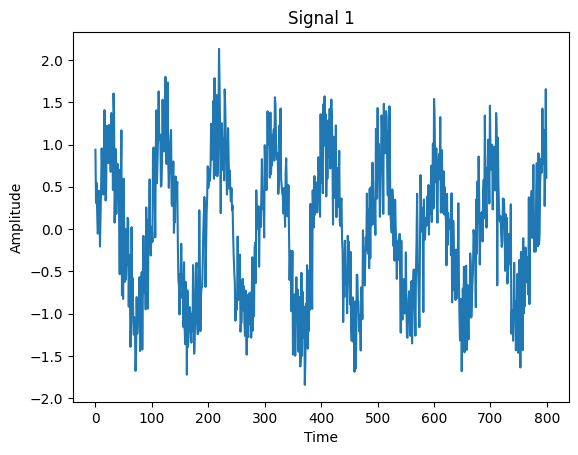

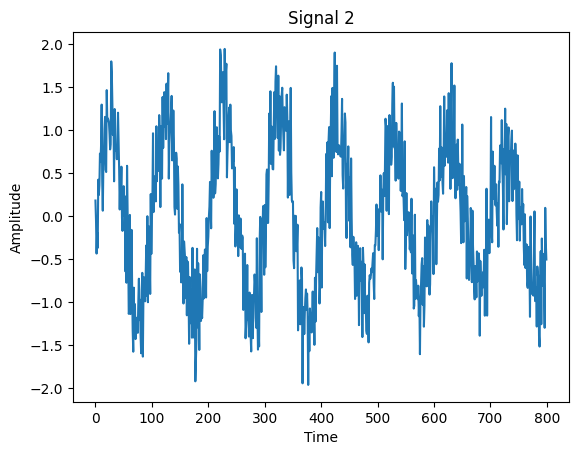

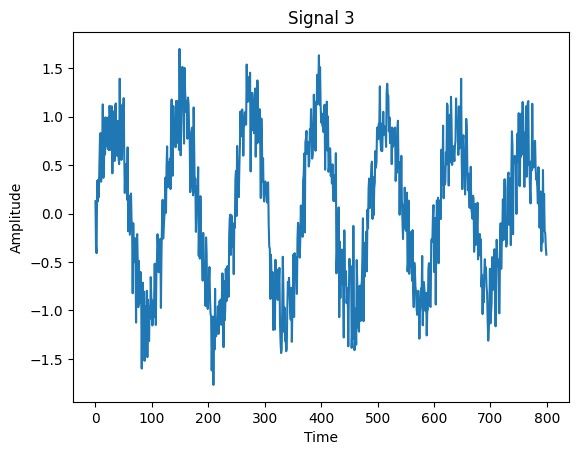

In [69]:
#Randomly plotting few segments

import random
import matplotlib.pyplot as plt

num_samples=3

samples = random.sample(list(df["signal"]), num_samples)

for i, sig in enumerate(samples, 1):
    plt.figure()
    plt.plot(sig)
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.title(f"Signal {i}")
    plt.show()



Next preprocessing of the signal is performed.Different steps involved in preprocessing are:

1. Detrend : To remove the slow drift due to sensor movement.
2. Band pass filtering : 0.5-8 Hz range is suitable for heart beats in PPG signal.Butterworth filter has maximally flat pass band so it wont distort the desired frequency range.
3. Normalization : Ensures the signal are in consistent range and helps the model to converge faster.

In [70]:
# preprocessing

from scipy.signal import butter, filtfilt, detrend

fs = 100  # sampling rate (Hz) – adjust if needed

def bandpass_filter(signal, low=0.5, high=8, fs=fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return filtfilt(b, a, signal)

def preprocess(signal):
    signal = detrend(signal)                  # detrend
    signal = bandpass_filter(signal)           # band-pass
    signal = (signal - np.mean(signal)) / np.std(signal)  # normalize
    return signal

# Apply to all signals
df["signal_proc"] = df["signal"].apply(preprocess)


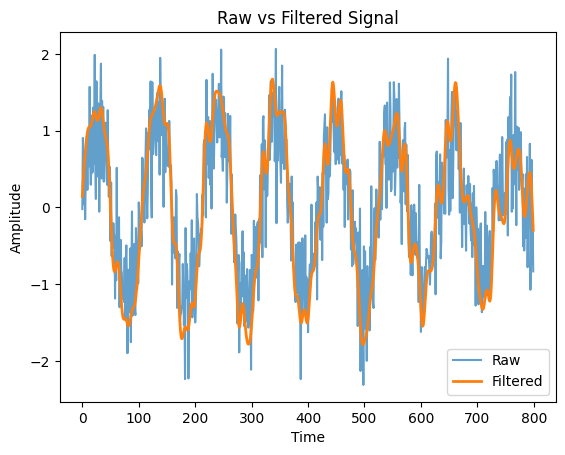

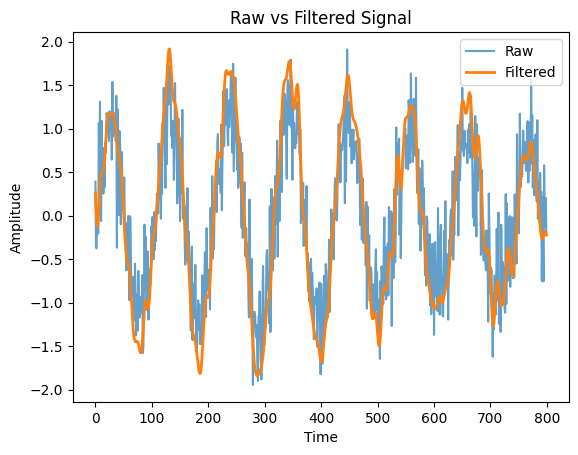

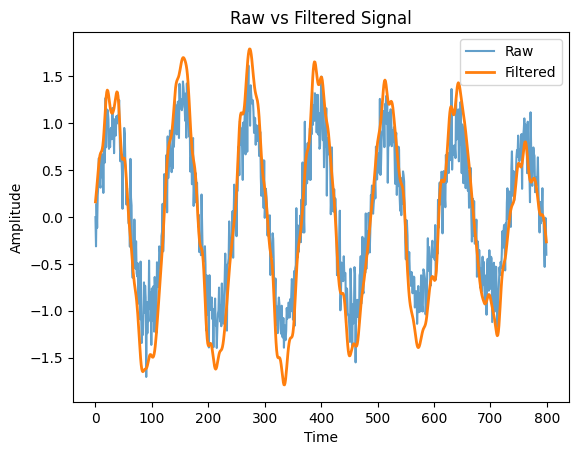

In [72]:


# Plotting raw vs filtered signal

rows = df.sample(3)

for i, row in rows.iterrows():
    raw = row["signal"]
    filt = row["signal_proc"]

    plt.figure()
    plt.plot(raw, label="Raw", alpha=0.7)
    plt.plot(filt, label="Filtered", linewidth=2)
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.title("Raw vs Filtered Signal")
    plt.legend()
    plt.show()


In [73]:
#Extracting features from the preprocessed signal

import numpy as np
from scipy.signal import find_peaks

fs = 100  # Hz

def extract_features(sig):
    mean = np.mean(sig)
    std = np.std(sig)
    ptp = np.ptp(sig)  # peak-to-peak
    energy = np.sum(sig**2)

    peaks, _ = find_peaks(sig, distance=fs*0.4)
    hr = len(peaks) * 60 / (len(sig) / fs)  # bpm

    return [mean, std, ptp, hr, energy]

X = np.vstack(df["signal_proc"].apply(extract_features))
y = df["label"].values


In [74]:
# Dividing the data into training and testing

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y_enc = le.fit_transform(y) # converting the labels( string ) to 1 and 0

X_train, X_val, y_train, y_val = train_test_split(
    X, y_enc, test_size=0.2, random_state=42)



In [75]:
# Checking data imbalance

from collections import Counter

print("Original label distribution:")
print(dict(Counter(y_enc)))

Original label distribution:
{np.int64(1): 48, np.int64(0): 52}


The dataset in not imbalanced so no additional measures are taken to balance the training dataset.

In [85]:
# Training the logistic regression model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=100)
model.fit(X_train, y_train)


LogisticRegression()

In [86]:
from sklearn.metrics import accuracy_score, f1_score

y_pred = model.predict(X_val)

acc = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

print("Accuracy:", acc)
print("F1 score:", f1)


Accuracy: 0.7
F1 score: 0.75


In [88]:
y_train_pred = model.predict(X_train)
print("Train Acc:", accuracy_score(y_train, y_train_pred))
print("Train F1:", f1_score(y_train, y_train_pred, average='macro'))

Train Acc: 0.8375
Train F1: 0.836246260431428


There is difference between the training and validation accuracy so there are chances of overfitting.

In [78]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
import numpy as np


In [79]:
def predict_signal(sig):
    feats = np.array(extract_features(sig)).reshape(1, -1)
    return model.predict(feats)[0]

def plot_signal(row):
    raw = row["signal"]
    filt = row["signal_proc"]
    pred = predict_signal(filt)

    plt.figure(figsize=(10,4))
    plt.plot(raw, label="Raw", alpha=0.6)
    plt.plot(filt, label="Filtered", linewidth=2)
    plt.legend()
    plt.title(f"Predicted label: {pred}")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.show()


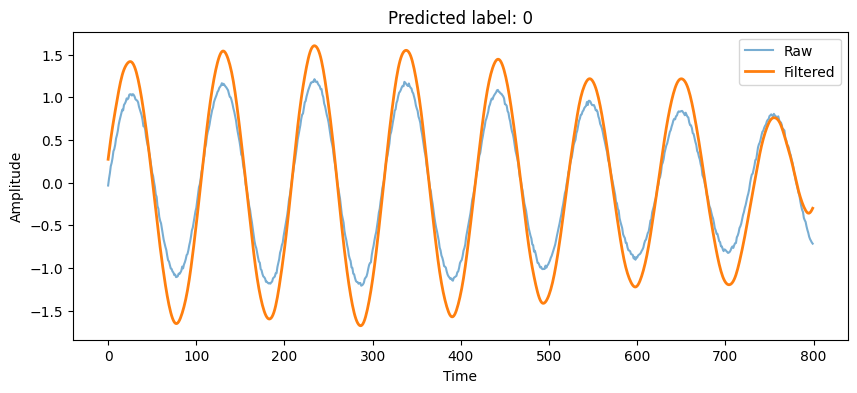

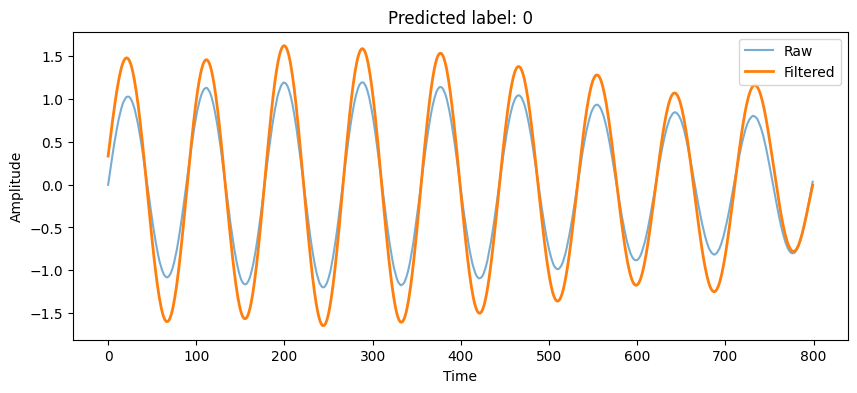

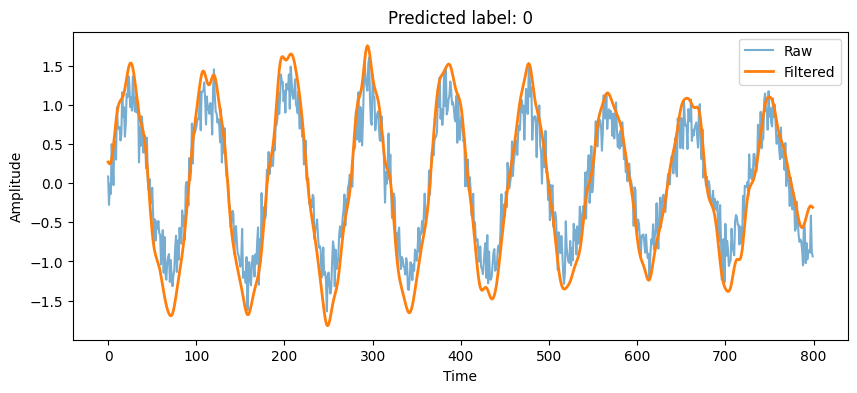

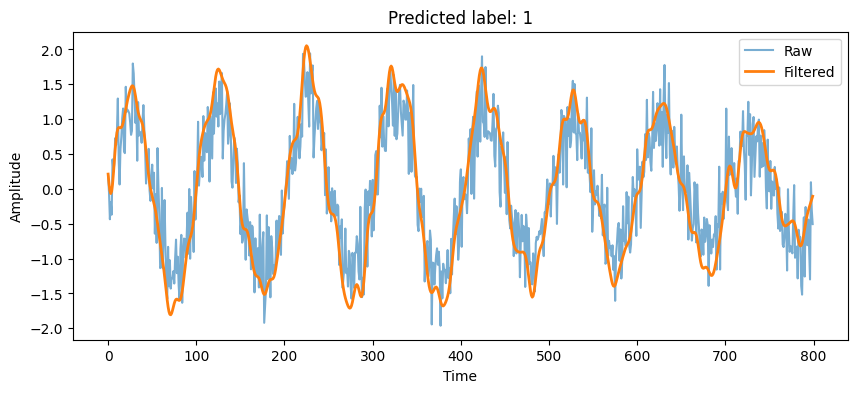

In [80]:
id_input = widgets.IntText(description="Enter ID:")
random_btn = widgets.Button(description="Random sample")

def show_by_id(_):
    row = df.loc[df["id"] == id_input.value].iloc[0]
    plot_signal(row)

def show_random(_):
    row = df.sample(1).iloc[0]
    plot_signal(row)

id_input.observe(show_by_id, names="value")
random_btn.on_click(show_random)

widgets.VBox([id_input, random_btn])
